In [1]:
import sys
from pathlib import Path
prediction_mode_path = Path("../module")
sys.path.append(prediction_mode_path.as_posix())
import models_creation as pred_model

import pandas as pd
import numpy as np

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
#from sklearn import tree

from matplotlib import pyplot as plt

import joblib

from mordred import Calculator, descriptors
import mordred
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem import Draw

import warnings
warnings.filterwarnings('ignore')

In [ ]:
load_prepared_data = pd.read_excel('../Data/QSPR_epoxidation_model_I.xlsx')
load_prepared_data.head(1)

,Reaction number,SMILES,Reaction ID,Reaction: Links to Reaxys,Reactant,Product,Reaction,Number of Reaction Steps,Time (Reaction Details) [h],Temperature (Reaction Details) [C],...,Reagent,SMILES ligand,SMILES mieszanina reakcyjna,% mol liganda,% mol magnezu,stężenie katalizatora [mol/dm3],stężenie substratu M,Solvent (Reaction Details),References,Links to Reaxys
0,1,CC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1,28455091,https://www.reaxys.com/reaxys/secured/hopinto....,4-methyl-chalcone,"(2R,3S)-epoxy-3-(4-methylphenyl)-1-phenylpropa...",CC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1>>CC1=CC=C(C=...,1,72,0,...,"tert.-butylhydroperoxide; (R,R)-(-)-2,6-bis[2-...",OC(C1=CC=CC=C1)(C2=CC=CC=C2)[C@@H](CCC3)N3CC4=...,CC(C)(OO)C.OC(C1=CC=CC=C1)(C2=CC=CC=C2)[C@@H](...,12,20,0.024,0.2,tetrahydrofuran; toluene,"Article; Jaszczewska-Adamczak, Joanna A.; Mlyn...",https://www.reaxys.com/reaxys/secured/hopinto....


In [ ]:
molecular_descriptors_df = pred_model.prepare_data('../Data/QSPR_epoxidation_model_I.xlsx')

100%|██████████████████████████████████████████████████████████████████████████████████| 41/41 [00:01<00:00, 28.30it/s]


Data size (rows, columns): (41, 1613)
Data size after first reduction (rows, columns): (41, 1285)
Data size after second reduction (rows, columns): (41, 1039)


In [4]:
molecular_descriptors_df.head()

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,piPC10,piPC2,piPC3,piPC4,piPC5,piPC6,piPC7,piPC8,piPC9,ee
0,21.096774,5.806774,3.096774,6.451613,154.935746,83.174801,1.660974,5.923665,3.939068,7.356725,...,6.248768,3.828641,4.356709,4.808111,5.323010,5.255866,5.476202,5.719492,6.006353,92
1,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,6.277700,3.828641,4.375757,4.832306,5.304548,5.232111,5.489067,5.679959,5.993806,55
2,26.400000,6.438830,3.433333,10.000000,156.786781,104.641286,1.662128,6.517330,7.696296,7.908921,...,6.459709,3.931826,4.465908,4.912655,5.417211,5.517704,5.844269,5.762837,6.101439,48
3,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,6.248768,3.828641,4.356709,4.808111,5.323010,5.255866,5.476202,5.719492,6.006353,97
4,22.000000,5.860000,3.142857,6.857143,153.799230,86.861521,1.707574,5.980396,4.190476,7.395751,...,6.123862,3.761200,4.297285,4.751433,5.237107,5.093750,5.418043,5.576896,5.901266,97


# EE

In [5]:
target = 'ee'
data = molecular_descriptors_df
data.head()

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,piPC10,piPC2,piPC3,piPC4,piPC5,piPC6,piPC7,piPC8,piPC9,ee
0,21.096774,5.806774,3.096774,6.451613,154.935746,83.174801,1.660974,5.923665,3.939068,7.356725,...,6.248768,3.828641,4.356709,4.808111,5.323010,5.255866,5.476202,5.719492,6.006353,92
1,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,6.277700,3.828641,4.375757,4.832306,5.304548,5.232111,5.489067,5.679959,5.993806,55
2,26.400000,6.438830,3.433333,10.000000,156.786781,104.641286,1.662128,6.517330,7.696296,7.908921,...,6.459709,3.931826,4.465908,4.912655,5.417211,5.517704,5.844269,5.762837,6.101439,48
3,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,6.248768,3.828641,4.356709,4.808111,5.323010,5.255866,5.476202,5.719492,6.006353,97
4,22.000000,5.860000,3.142857,6.857143,153.799230,86.861521,1.707574,5.980396,4.190476,7.395751,...,6.123862,3.761200,4.297285,4.751433,5.237107,5.093750,5.418043,5.576896,5.901266,97


## The best model is: Random Forest (correlation_threshold = 0.48, 5 features, 4 estimators, random_state=28)

In [6]:
model, train_r2_, test_r2_, hist1, hist2, target_column_name, training_data_RMSE, test_data_RMSE  = pred_model.prepare_data_and_create_model(molecular_descriptors_df=data, 
                                                                                                    correlation_threshold=0.48, 
                                                                                                    standardization=False, 
                                                                                                    model_type='RandomForestRegressor',
                                                                                                    n_estimators_=4,
                                                                                                    target_column_name = target,
                                                                                                    random_state=28,
                                                                                                    train_test_split_=True, 
                                                                                                    verbose=True)
print("R^2 score: " + str(r2_score(data[target], model.predict(data[hist2['molecular descriptor name']]))))
print("Mean squared error: "+str(mean_squared_error(data[target], model.predict(data[hist2['molecular descriptor name']]))))
print('Mean absolute error: ' + str(mean_absolute_error(data[target], model.predict(data[hist2['molecular descriptor name']]))))
print("Root Mean Square Error: "+ str(math.sqrt(mean_squared_error(data[target], model.predict(data[hist2['molecular descriptor name']])))))

I am not doing standardization...
  molecular descriptor name
0                    AATS0Z
1                  AATS0are
2                    AATS0d
3                   AATS0dv
4                    AATS0i
  molecular descriptor name  corr_value
0                    AATS0Z    0.161586
1                  AATS0are   -0.102104
2                    AATS0d    0.106173
3                   AATS0dv   -0.052551
4                    AATS0i   -0.189223
  molecular descriptor name  corr_value  absolute correlation value
0                    AATS0Z    0.161586                    0.161586
1                  AATS0are   -0.102104                    0.102104
2                    AATS0d    0.106173                    0.106173
3                   AATS0dv   -0.052551                    0.052551
4                    AATS0i   -0.189223                    0.189223
    molecular descriptor name  corr_value  absolute correlation value
155                    AMID_O   -0.500222                    0.500222
342       

In [7]:
# save
joblib.dump(model, "Random_forest/random_forest_model_4_estimators_EE.joblib")

['Random_forest/random_forest_model_4_estimators_EE.joblib']

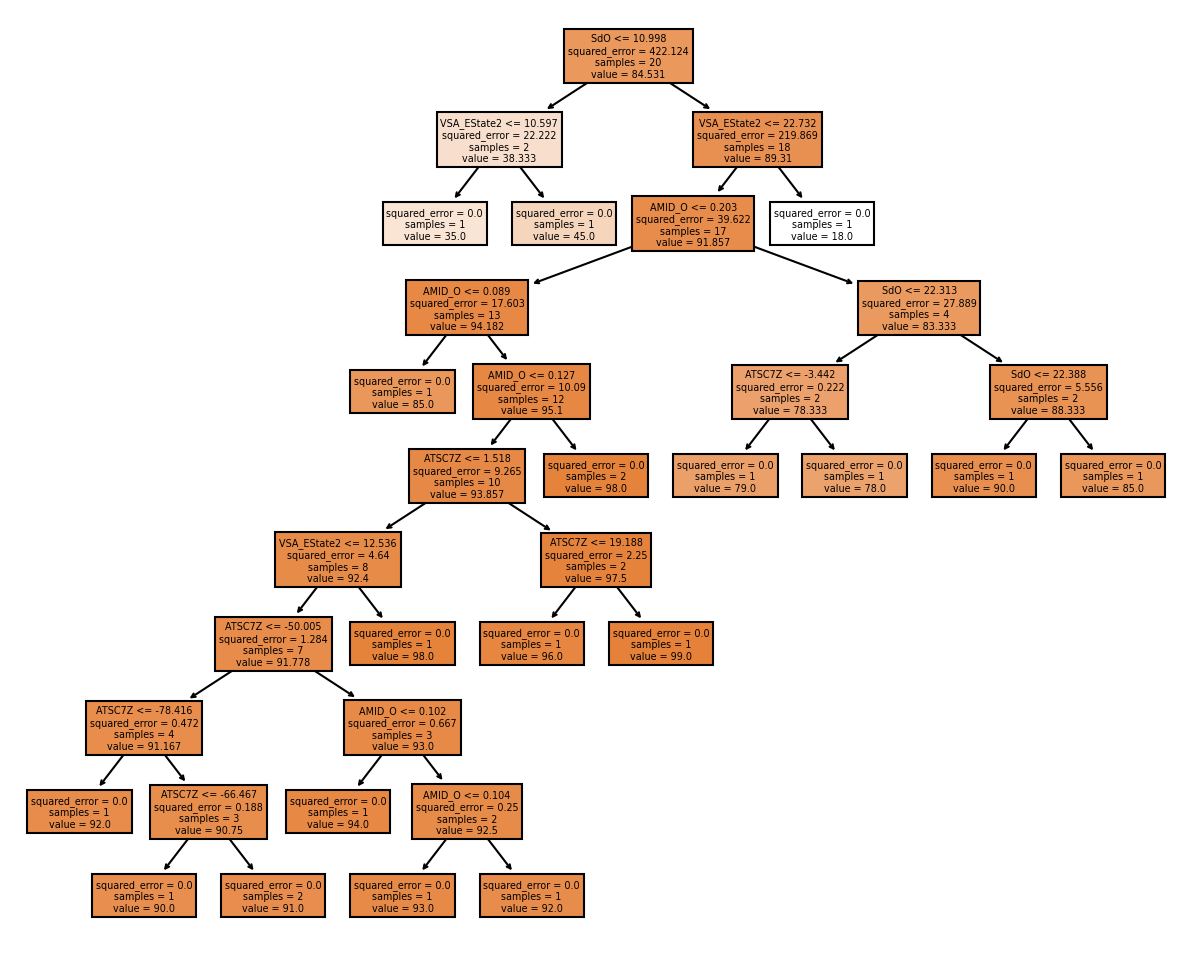

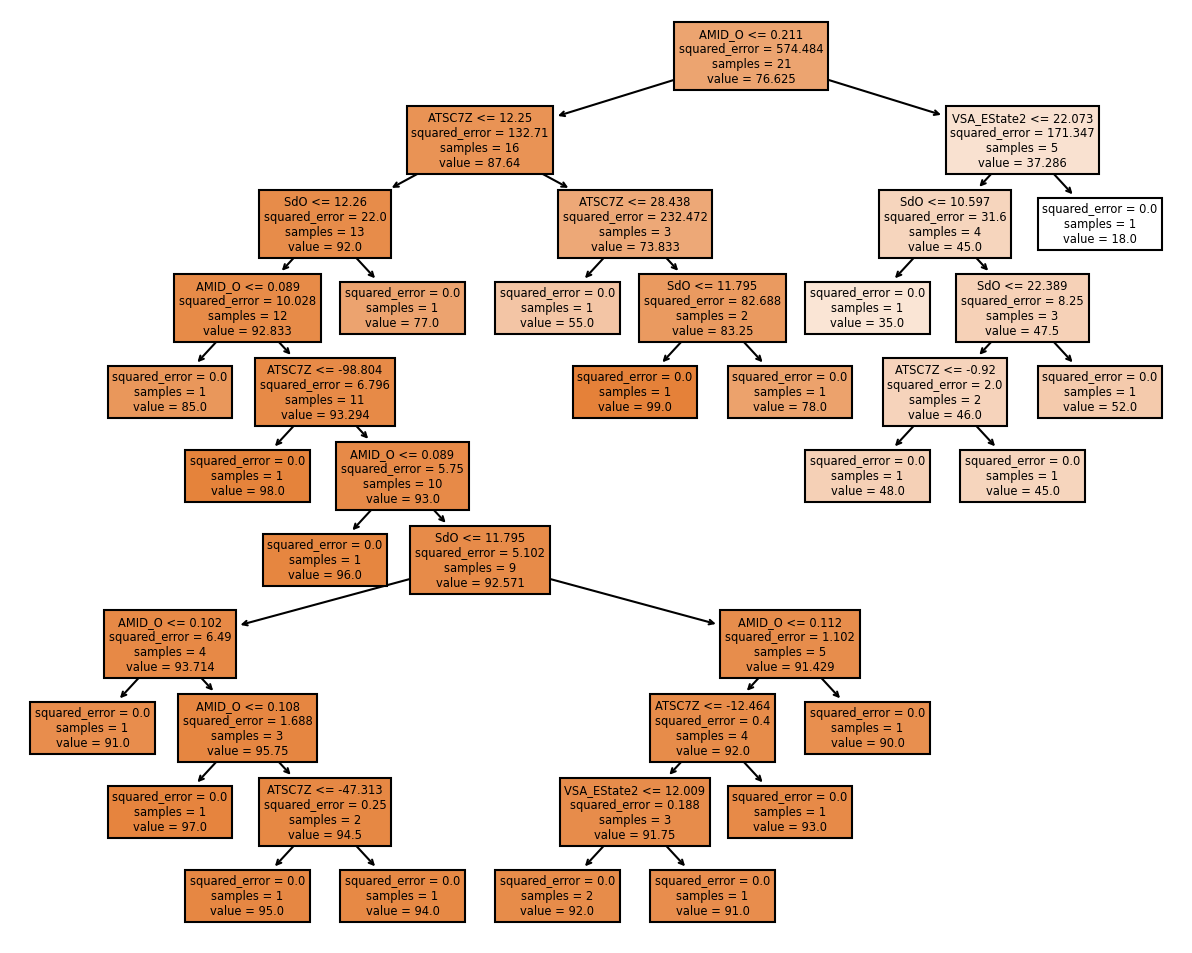

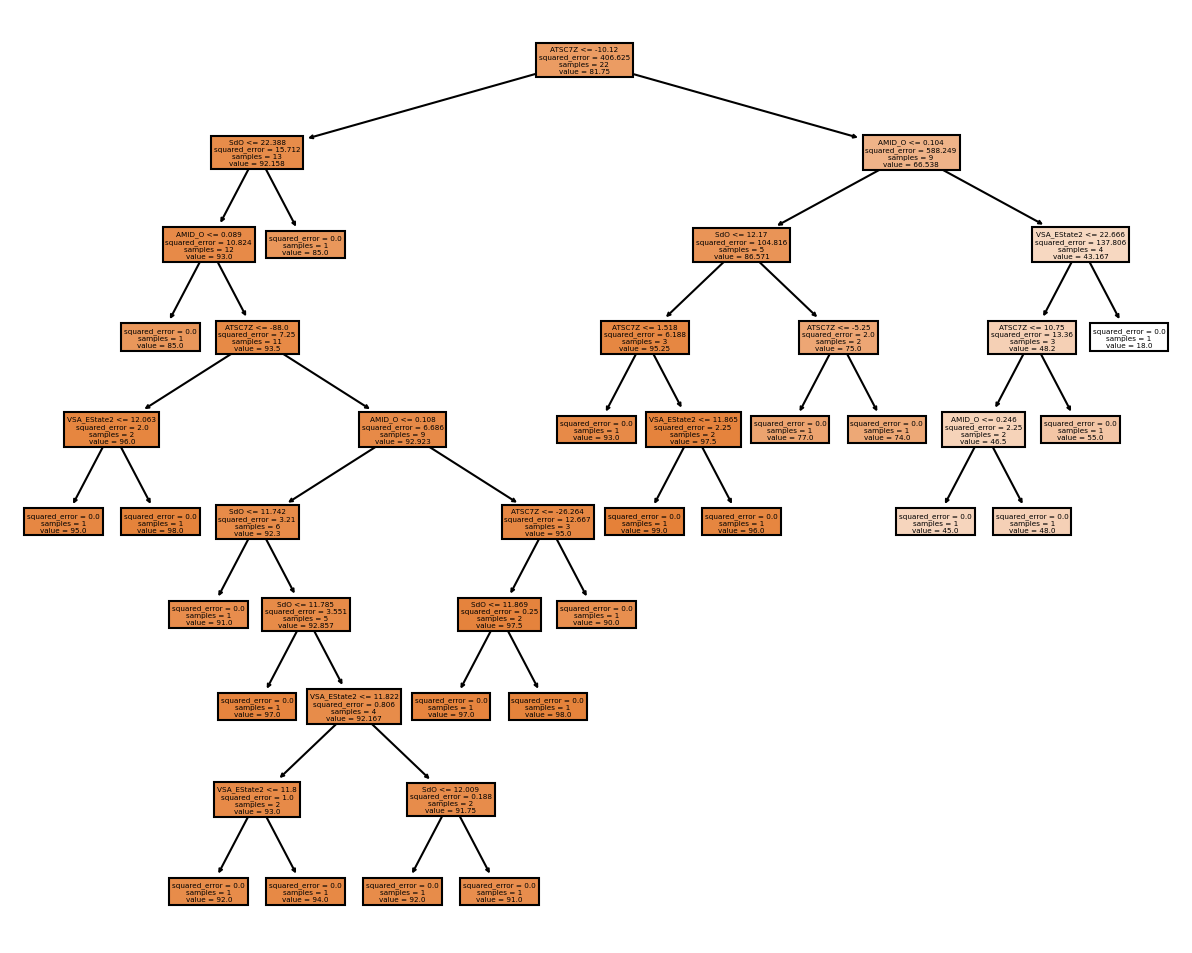

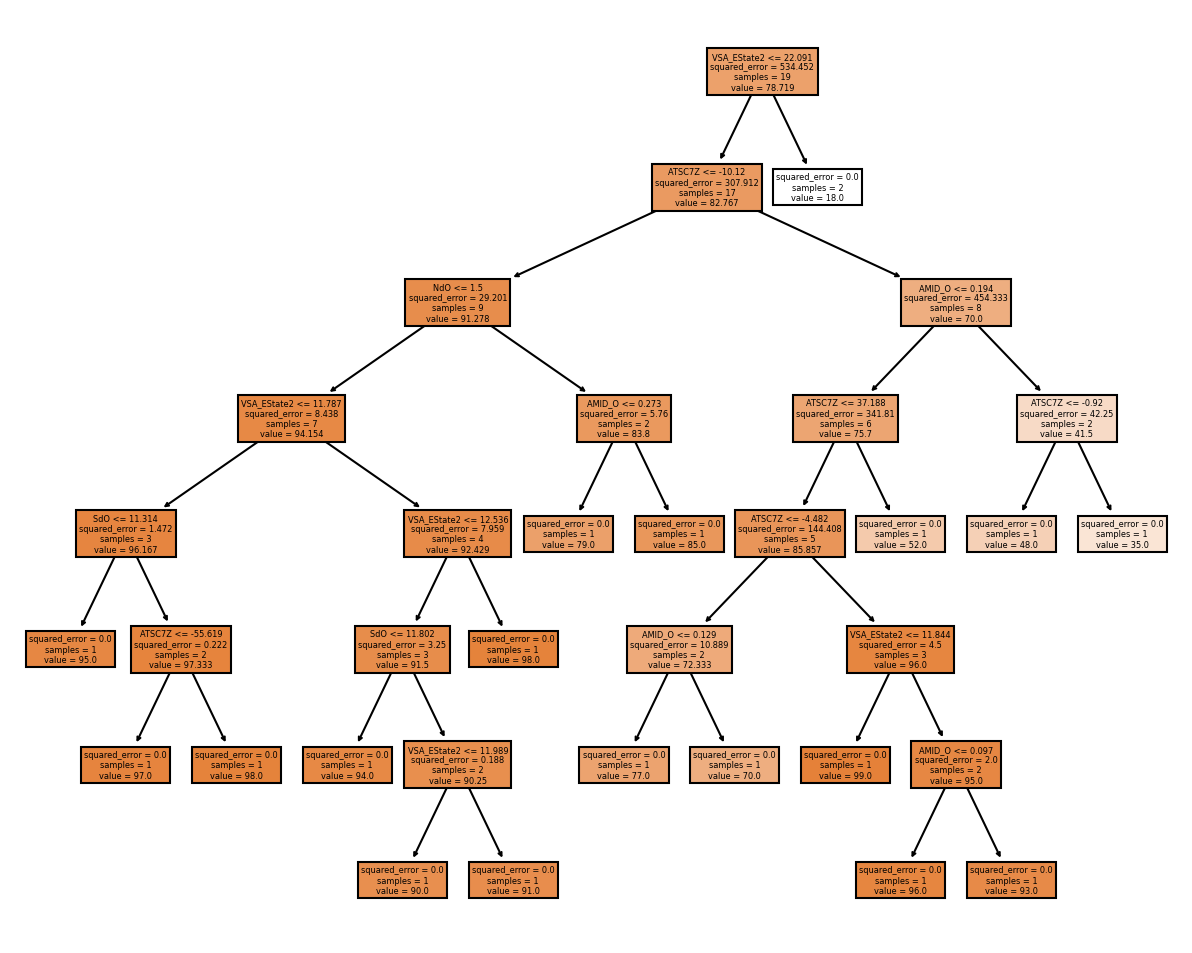

In [8]:
for x, decision_tree in enumerate(model.estimators_):
    plt.figure(figsize=(10,8), dpi=150)
    plot_tree(decision_tree, feature_names=list(hist2['molecular descriptor name']),
             filled=True)
    plt.savefig('Random_forest/random_forest_4_'+str(x)+'_model_EE.pdf',bbox_inches = "tight")

In [9]:
hist2

,molecular descriptor name,corr_value,absolute correlation value
155,AMID_O,-0.500222,0.500222
342,ATSC7Z,-0.484674,0.484674
687,NdO,-0.508435,0.508435
759,SdO,-0.495490,0.495490
915,VSA_EState2,-0.491040,0.491040


## PREDICTIONS

In [1]:
import sys
from pathlib import Path
prediction_mode_path = Path("../module")
sys.path.append(prediction_mode_path.as_posix())
import models_creation as pred_model

import pandas as pd
import numpy as np

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
#from sklearn import tree

from matplotlib import pyplot as plt

import joblib

from mordred import Calculator, descriptors
import mordred
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem import Draw

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel('../Data/5_test_reactions.xlsx')

In [3]:
df.head(1)

,Reaction ID,Reaction: Links to Reaxys,Reactant,Product,Bin,SMILES,Reaction,Number of Reaction Steps,Time (Reaction Details) [h],Temperature (Reaction Details) [C],...,Reagent,SMILES ligand,SMILES mieszanina reakcyjna,% mol liganda,% mol magnezu,stężenie katalizatora [mol/dm3],stężenie substratu M,Solvent (Reaction Details),References,Links to Reaxys
0,28833233,https://www.reaxys.com/reaxys/secured/hopinto....,4'-chlorochalcone,"trans-(2R,3S)-2,3-epoxy-3-phenyl-1-(4-chloroph...",122716,ClC1=CC=C(C=C1)C(=O)C=CC1=CC=CC=C1,ClC1=CC=C(C=C1)C(=O)C=CC1=CC=CC=C1>>ClC1=CC=C(...,1,72,0,...,"tert.-butylhydroperoxide; (R,R)-(-)-2,6-bis[2-...",OC(C1=CC=CC=C1)(C2=CC=CC=C2)[C@@H](CCC3)N3CC4=...,CC(C)(OO)C.OC(C1=CC=CC=C1)(C2=CC=CC=C2)[C@@H](...,12,20,0.024,0.2,tetrahydrofuran; toluene,"Article; Jaszczewska-Adamczak, Joanna A.; Mlyn...",https://www.reaxys.com/reaxys/secured/hopinto....


In [4]:
molecular_descriptors_df = pred_model.prepare_data('../Data/5_test_reactions.xlsx')

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  6.96it/s]

Data size (rows, columns): (5, 1613)
Data size after first reduction (rows, columns): (5, 1285)
Data size after second reduction (rows, columns): (5, 979)


In [5]:
model = joblib.load("Random_forest/random_forest_model_4_estimators_EE.joblib")

In [6]:
list(model.feature_names_in_)

['AMID_O', 'ATSC7Z', 'NdO', 'SdO', 'VSA_EState2']

In [7]:
predicted_activity = model.predict(molecular_descriptors_df[list(model.feature_names_in_)])

In [8]:
predicted_activity

array([92.25, 38.25, 85.75, 66.5 , 95.25])

In [9]:
df['ee']

0    93
1    44
2    88
3    99
4    88
Name: ee, dtype: int64

In [10]:
r2_score(list(df['ee']), list(predicted_activity))

0.4039580303345107

In [11]:
np.sqrt(r2_score(list(df['ee']), list(predicted_activity)))

0.6355769271571386

In [12]:
print("MSE "+str(mean_squared_error(list(df['ee']), list(predicted_activity))))
print("MAE "+str(mean_absolute_error(list(df['ee']), list(predicted_activity))))
print("RMSE "+str(math.sqrt(mean_squared_error(list(df['ee']), list(predicted_activity)))))

MSE 229.5
MAE 9.7
RMSE 15.149257407543116


In [1]:
import sys
from pathlib import Path
prediction_mode_path = Path("../module")
sys.path.append(prediction_mode_path.as_posix())
import models_creation as pred_model

import pandas as pd
import numpy as np

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
#from sklearn import tree

from matplotlib import pyplot as plt

import joblib

from mordred import Calculator, descriptors
import mordred
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem import Draw

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel('../Data/pred_model_I_i_II.xlsx')
df.head(1)

,SMILES,0,1,2,3,4,5,6,7,8,9,9.1,9.2,9.3,9.4
0,O=C(C1=CC=CC=C1)C(O2)C2(C(F)(F)F)C3=CC=CC=C3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
molecular_descriptors_df = pred_model.prepare_data('../Data/predykcja_model_I_i_II.xlsx')

100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  5.91it/s]


Data size (rows, columns): (4, 1613)
Data size after first reduction (rows, columns): (4, 1442)
Data size after second reduction (rows, columns): (4, 1141)


In [4]:
model = joblib.load("Random_forest/random_forest_model_4_estimators_EE.joblib")

In [5]:
list(model.feature_names_in_)

['AMID_O', 'ATSC7Z', 'NdO', 'SdO', 'VSA_EState2']

In [6]:
predicted_activity = model.predict(molecular_descriptors_df[list(model.feature_names_in_)])

In [7]:
predicted_activity

array([96.25, 78.75, 53.25, 75.25])